<a href="https://colab.research.google.com/github/anindita012003/Customer-churn-prediction/blob/main/heathcare_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sqlite3

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/dataset/healthcare_dataset.csv")

In [ ]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [ ]:
df.shape

(55500, 15)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [ ]:
df.describe()

,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


In [ ]:
df.isnull().sum()

,0
Name,0
Age,0
Gender,0
Blood Type,0
Medical Condition,0
Date of Admission,0
Doctor,0
Hospital,0
Insurance Provider,0
Billing Amount,0


In [ ]:
df.duplicated().sum()

np.int64(534)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df['Date of Admission']=pd.to_datetime(df['Date of Admission'])

In [ ]:
df['Discharge Date']=pd.to_datetime(df['Discharge Date'])

In [ ]:
df['Hospital stay']=(df['Discharge Date']-df['Date of Admission']).dt.days

In [ ]:
df.head(10)

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Hospital stay
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal,2
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,6
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal,15
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal,30
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal,20
5,EMILY JOHNSOn,36,Male,A+,Asthma,2023-12-20,Taylor Newton,Nunez-Humphrey,UnitedHealthcare,48145.110951,389,Urgent,2023-12-24,Ibuprofen,Normal,4
6,edwArD EDWaRDs,21,Female,AB-,Diabetes,2020-11-03,Kelly Olson,Group Middleton,Medicare,19580.872345,389,Emergency,2020-11-15,Paracetamol,Inconclusive,12
7,CHrisTInA MARtinez,20,Female,A+,Cancer,2021-12-28,Suzanne Thomas,"Powell Robinson and Valdez,",Cigna,45820.462722,277,Emergency,2022-01-07,Paracetamol,Inconclusive,10
8,JASmINe aGuIlaR,82,Male,AB+,Asthma,2020-07-01,Daniel Ferguson,Sons Rich and,Cigna,50119.222792,316,Elective,2020-07-14,Aspirin,Abnormal,13
9,ChRISTopher BerG,58,Female,AB-,Cancer,2021-05-23,Heather Day,Padilla-Walker,UnitedHealthcare,19784.631062,249,Elective,2021-06-22,Paracetamol,Inconclusive,30


In [ ]:
np.mean(df['Billing Amount'])

np.float64(25544.306284383965)

In [ ]:
np.max(df['Billing Amount'])

52764.276736469175

In [ ]:
np.min(df['Billing Amount'])

-2008.4921398591305

In [ ]:
df['Medical Condition'].value_counts()

,count
Medical Condition,
Arthritis,9218
Diabetes,9216
Hypertension,9151
Obesity,9146
Cancer,9140
Asthma,9095


In [ ]:
df.groupby('Medical Condition')['Billing Amount'].mean()

,Billing Amount
Medical Condition,
Arthritis,25511.783246
Asthma,25633.461696
Cancer,25152.322947
Diabetes,25660.478635
Hypertension,25503.058720
Obesity,25804.361902


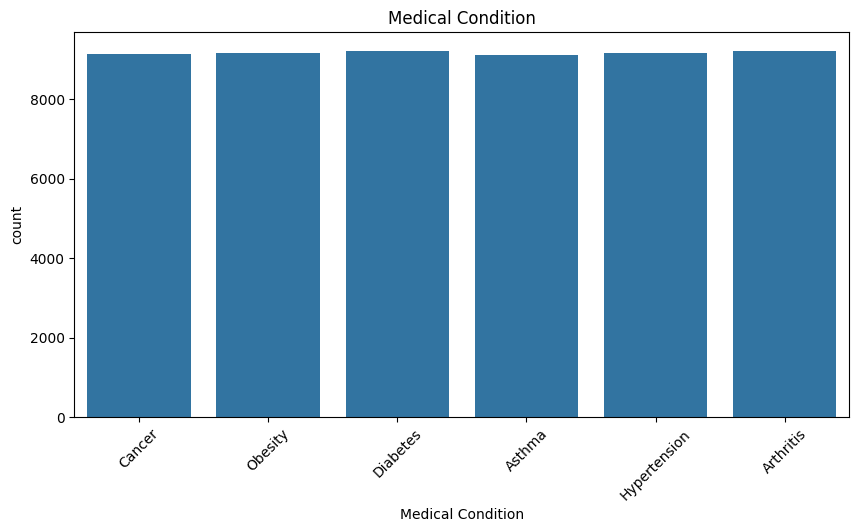

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='Medical Condition',data=df)
plt.title('Medical Condition')
plt.xticks(rotation=45)
plt.show()

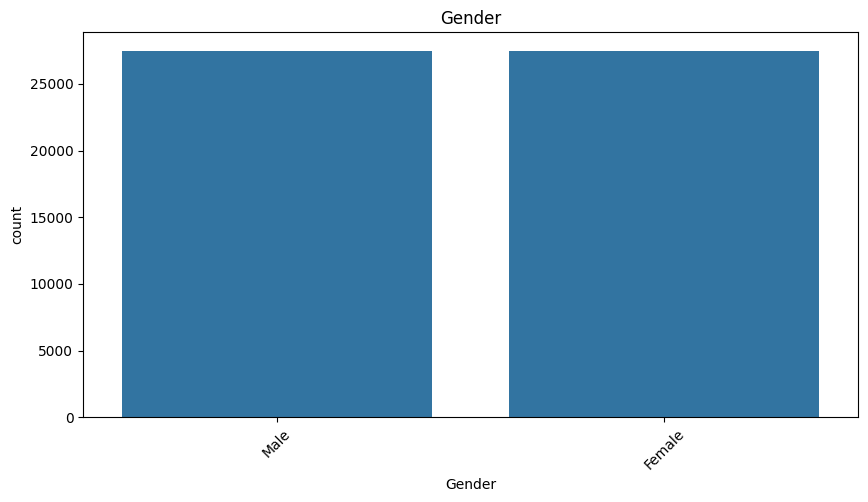

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='Gender',data=df)
plt.title('Gender')
plt.xticks(rotation=45)
plt.show()

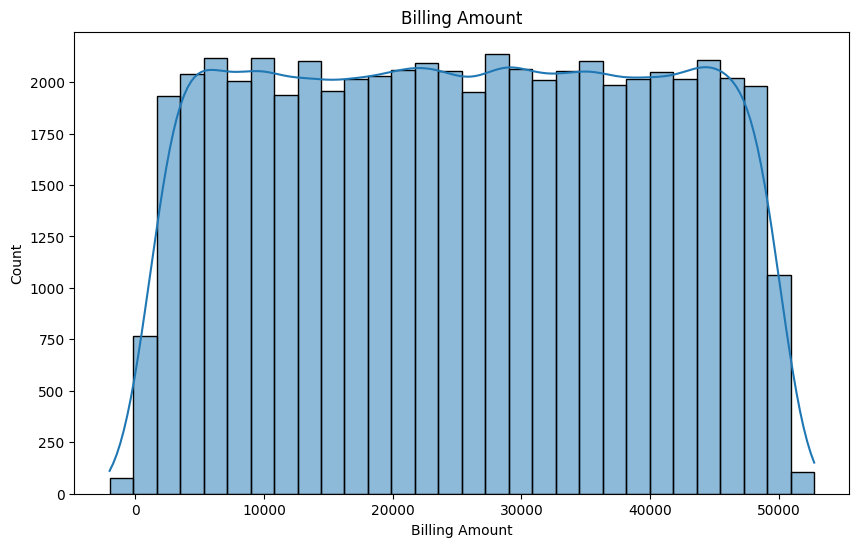

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df['Billing Amount'],bins=30,kde=True)
plt.title('Billing Amount')
plt.show()

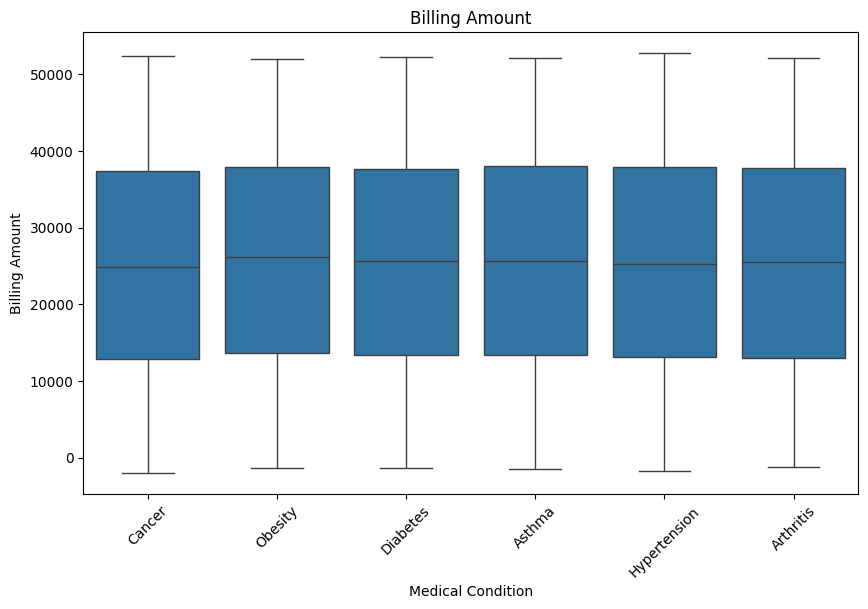

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Medical Condition',y='Billing Amount',data=df)
plt.title('Billing Amount')
plt.xticks(rotation=45)
plt.show()

In [ ]:
numeric_df=df.select_dtypes(include=np.number)

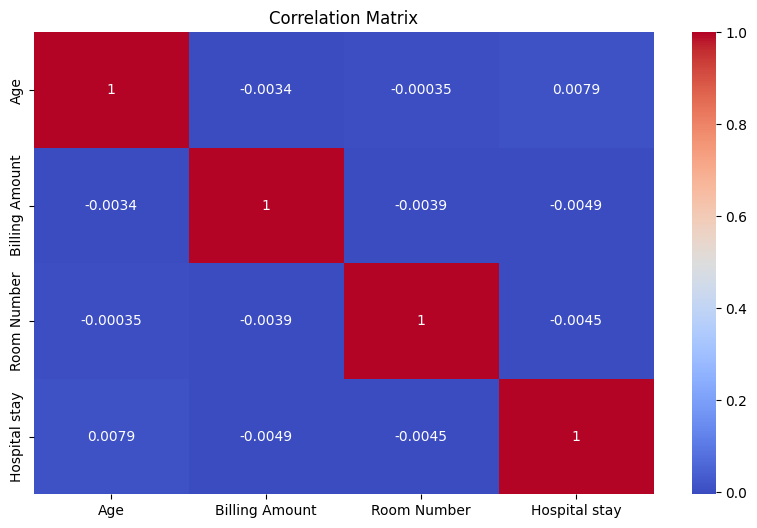

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(),annot=True,cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
conn=sqlite3.connect('healthcare.db')
df.to_sql('heathcare',conn,if_exists='replace',index=False)

54966

In [ ]:
query=""" select name,`Billing Amount` from heathcare order by `Billing Amount` desc limit 10"""
pd.read_sql(query,conn)

,Name,Billing Amount
0,tOdd CARrILlO,52764.276736
1,kARen klInE,52373.032374
2,kARen klInE,52373.032374
3,DAVId SanDOvaL,52271.663747
4,kathRYN GoNzales,52211.852966
5,BRETT mARshAll,52181.837792
6,LAuRie hOod,52170.036854
7,LAuRie hOod,52170.036854
8,JUstIn CLark,52154.237722
9,sCotT pOWElL,52102.240889


In [ ]:
query=""" select `Medical Condition`,avg(`Billing Amount`) as avg_bill from heathcare group by `Medical Condition`"""
pd.read_sql(query,conn)

,Medical Condition,avg_bill
0,Arthritis,25511.783246
1,Asthma,25633.461696
2,Cancer,25152.322947
3,Diabetes,25660.478635
4,Hypertension,25503.058720
5,Obesity,25804.361902


In [ ]:
query=""" select Gender,count(*) as total from heathcare group by Gender"""
pd.read_sql(query,conn)

,Gender,total
0,Female,27470
1,Male,27496


In [ ]:
query=""" select Name,`Medical Condition`,`Billing Amount` ,rank() over(order by `Billing Amount` desc)as rank from heathcare"""
pd.read_sql(query,conn)

,Name,Medical Condition,Billing Amount,rank
0,tOdd CARrILlO,Hypertension,52764.276736,1
1,kARen klInE,Cancer,52373.032374,2
2,kARen klInE,Cancer,52373.032374,2
3,DAVId SanDOvaL,Hypertension,52271.663747,4
4,kathRYN GoNzales,Diabetes,52211.852966,5
...,...,...,...,...
54961,tErRy WILSOn,Diabetes,-1316.618581,54961
54962,JOsEPH robBins,Hypertension,-1428.843941,54963
54963,joHn hahN,Asthma,-1520.420555,54964
54964,EMMA savAGE,Hypertension,-1660.009373,54965


In [ ]:
from pyspark.sql import SparkSession


In [ ]:
spark=SparkSession.builder.appName('healthcare').getOrCreate()

In [ ]:
spark_df=spark.read.csv('/content/drive/MyDrive/dataset/healthcare_dataset.csv',header=True,inferSchema=True)

In [ ]:
spark_df.printSchema()

root
 |-- Name: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Blood Type: string (nullable = true)
 |-- Medical Condition: string (nullable = true)
 |-- Date of Admission: date (nullable = true)
 |-- Doctor: string (nullable = true)
 |-- Hospital: string (nullable = true)
 |-- Insurance Provider: string (nullable = true)
 |-- Billing Amount: double (nullable = true)
 |-- Room Number: integer (nullable = true)
 |-- Admission Type: string (nullable = true)
 |-- Discharge Date: date (nullable = true)
 |-- Medication: string (nullable = true)
 |-- Test Results: string (nullable = true)



In [ ]:
spark_df.groupBy('Medical Condition').count().show()

+-----------------+-----+
|Medical Condition|count|
+-----------------+-----+
|          Obesity| 9231|
|         Diabetes| 9304|
|        Arthritis| 9308|
|     Hypertension| 9245|
|           Cancer| 9227|
|           Asthma| 9185|
+-----------------+-----+



In [ ]:
from pyspark.sql.functions import avg
spark_df.groupBy('Medical Condition').agg(avg('Billing Amount')).show()

+-----------------+-------------------+
|Medical Condition|avg(Billing Amount)|
+-----------------+-------------------+
|          Obesity| 25805.971259050966|
|         Diabetes| 25638.405577382244|
|        Arthritis| 25497.327055738246|
|     Hypertension| 25497.095760788983|
|           Cancer| 25161.792707059732|
|           Asthma| 25635.249358698507|
+-----------------+-------------------+



In [ ]:
disease_count=df['Medical Condition'].value_counts()

In [ ]:
disease_count

,count
Medical Condition,
Arthritis,9218
Diabetes,9216
Hypertension,9151
Obesity,9146
Cancer,9140
Asthma,9095


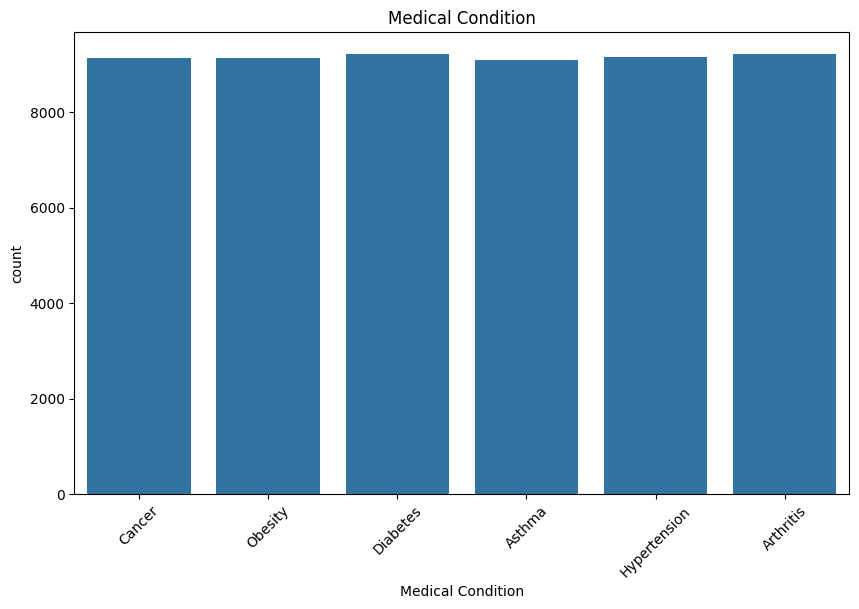

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(x='Medical Condition',data=df)
plt.title('Medical Condition')
plt.xticks(rotation=45)
plt.show()

In [ ]:
billing_by_disease=df.groupby('Medical Condition')['Billing Amount'].sum().sort_values(ascending=False)
print(billing_by_disease)

Medical Condition
Diabetes        2.364870e+08
Obesity         2.360067e+08
Arthritis       2.351676e+08
Hypertension    2.333785e+08
Asthma          2.331363e+08
Cancer          2.298922e+08
Name: Billing Amount, dtype: float64


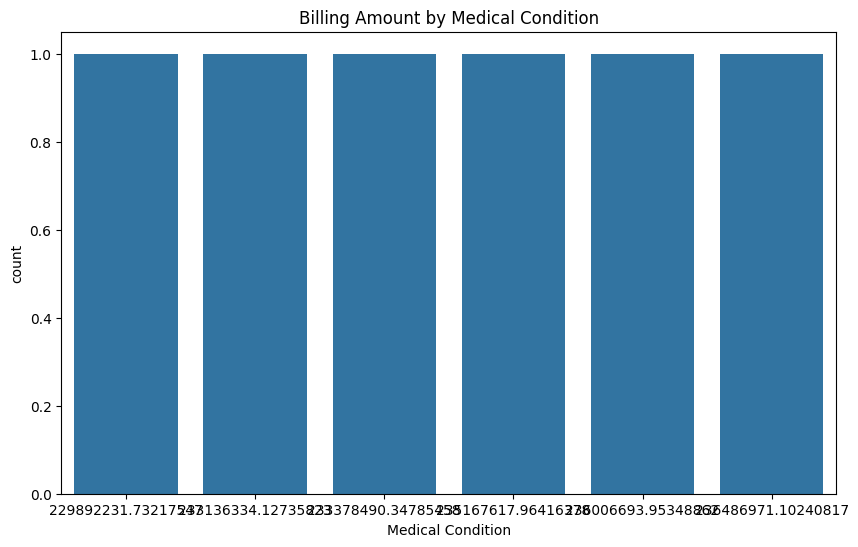

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(x=billing_by_disease ,data=df)
plt.title('Billing Amount by Medical Condition')
plt.xlabel('Medical Condition')
plt.show()

In [ ]:
df['Hospital stay']=(df['Discharge Date']-df['Date of Admission']).dt.days

In [ ]:
avg_stay=df.groupby('Medical Condition')['Hospital stay'].mean()
print(avg_stay)

Medical Condition
Arthritis       15.504231
Asthma          15.677295
Cancer          15.501204
Diabetes        15.430664
Hypertension    15.436236
Obesity         15.447627
Name: Hospital stay, dtype: float64


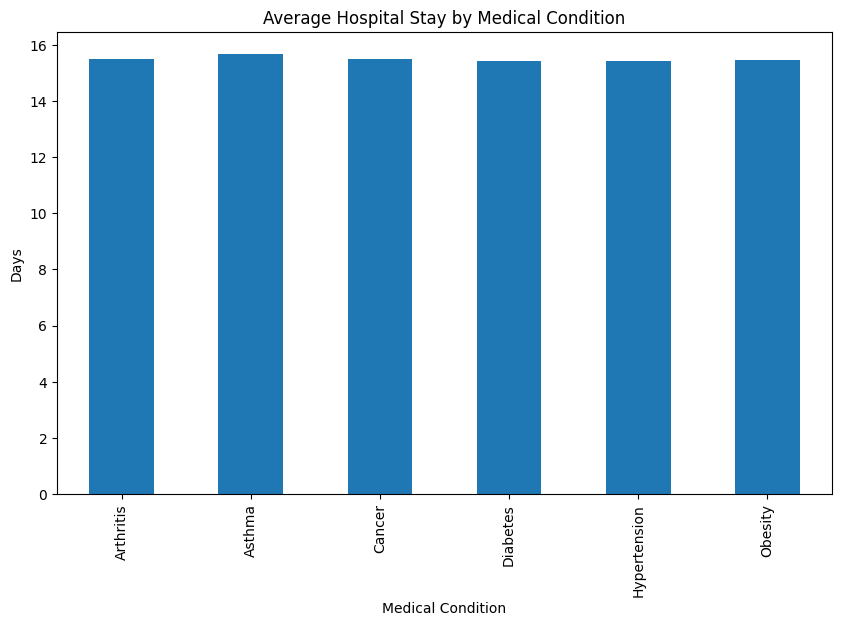

In [ ]:
plt.figure(figsize=(10,6))
avg_stay.plot(kind='bar')
plt.title('Average Hospital Stay by Medical Condition')
plt.xlabel('Medical Condition')
plt.ylabel('Days')
plt.show()

In [ ]:
insurance_count=df['Insurance Provider'].value_counts()
print(insurance_count)

Insurance Provider
Cigna               11139
Medicare            11039
UnitedHealthcare    11014
Blue Cross          10952
Aetna               10822
Name: count, dtype: int64


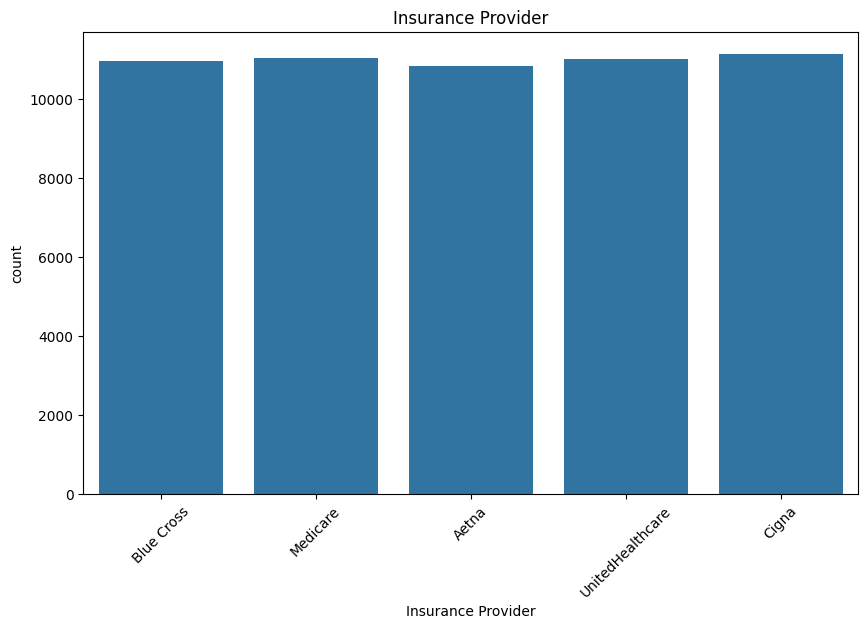

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(x='Insurance Provider',data=df)
plt.title('Insurance Provider')
plt.xticks(rotation=45)
plt.show()

In [ ]:
df['Admission Type'].value_counts()

,count
Admission Type,
Elective,18473
Urgent,18391
Emergency,18102


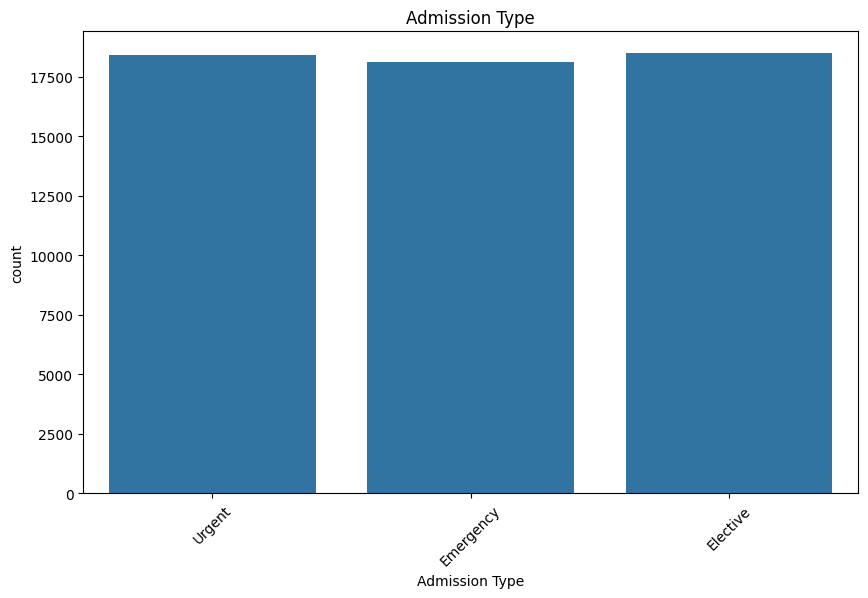

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(x='Admission Type',data=df)
plt.title('Admission Type')
plt.xticks(rotation=45)
plt.show()

In [ ]:
gender_disease=pd.crosstab(df['Gender'],df['Medical Condition'])
print(gender_disease)

Medical Condition  Arthritis  Asthma  Cancer  Diabetes  Hypertension  Obesity
Gender                                                                       
Female                  4642    4511    4566      4609          4569     4573
Male                    4576    4584    4574      4607          4582     4573


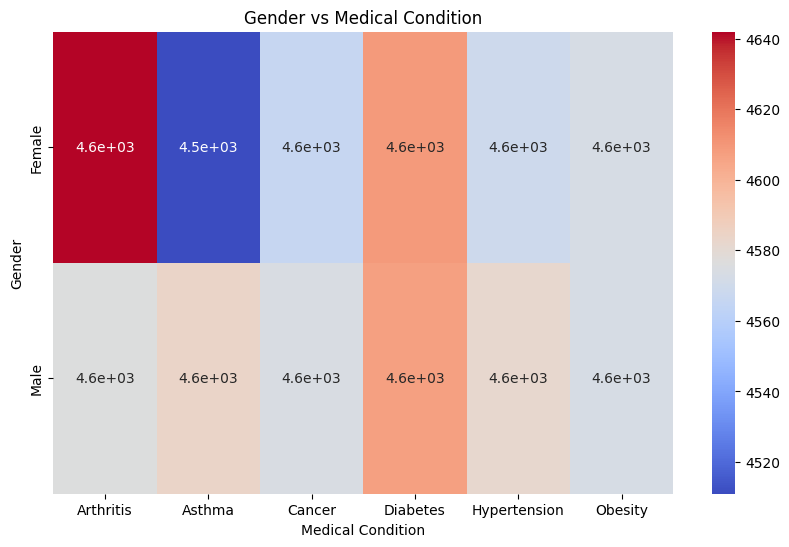

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(gender_disease,annot=True,cmap='coolwarm')
plt.title('Gender vs Medical Condition')
plt.show()

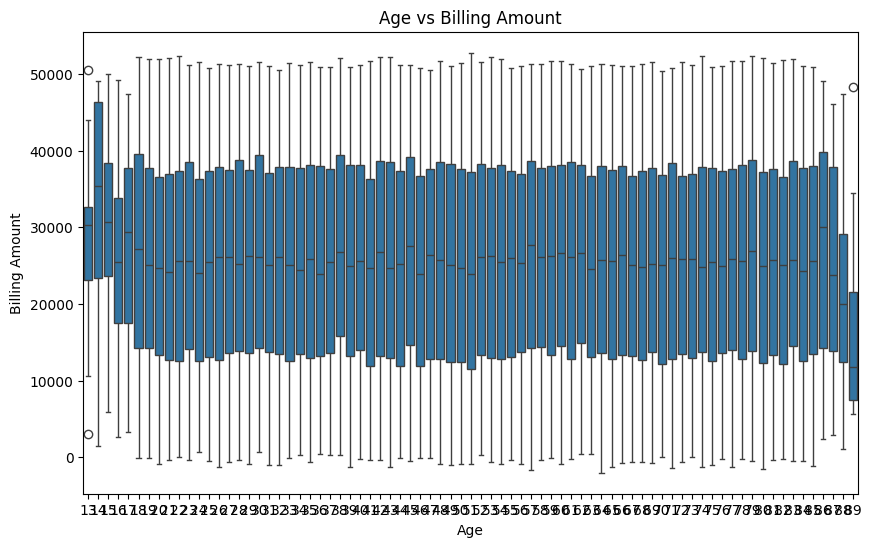

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Age',y='Billing Amount',data=df)
plt.title('Age vs Billing Amount')
plt.show()

In [ ]:
docter_count=df['Doctor'].value_counts()
print(docter_count)

Doctor
Michael Smith        27
John Smith           22
Robert Smith         21
James Smith          20
Michael Johnson      20
                     ..
Ashley Patton DDS     1
Wanda Stark           1
Tiffany Gibson        1
Christy Klein         1
Jeffery Christian     1
Name: count, Length: 40341, dtype: int64


In [ ]:
medication_result=pd.crosstab(df['Medication'],df['Test Results'])

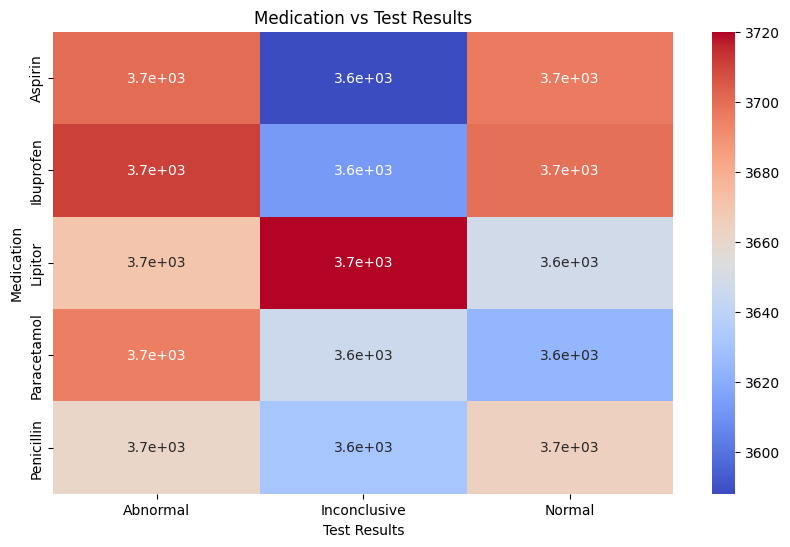

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(medication_result,annot=True,cmap='coolwarm')
plt.title('Medication vs Test Results')
plt.show()

In [ ]:
df['Age Group']=pd.cut(df['Age'],bins=[0,18,30,50,100],labels=['0-18','19-30','31-50','51-100'])

In [ ]:
age_disease=pd.crosstab(df['Age Group'],['Medical Condition'])
print(age_disease)

col_0      Medical Condition
Age Group                   
0-18                     886
19-30                   9519
31-50                  16167
51-100                 28394


In [ ]:
query=""" select count(*) as total_patients from heathcare"""
pd.read_sql(query,conn)

,total_patients
0,54966


In [ ]:
spark_df.select('Name','Age','Gender','Medical Condition').show(5)

+-------------+---+------+-----------------+
|         Name|Age|Gender|Medical Condition|
+-------------+---+------+-----------------+
|Bobby JacksOn| 30|  Male|           Cancer|
| LesLie TErRy| 62|  Male|          Obesity|
|  DaNnY sMitH| 76|Female|          Obesity|
| andrEw waTtS| 28|Female|         Diabetes|
|adrIENNE bEll| 43|Female|           Cancer|
+-------------+---+------+-----------------+
only showing top 5 rows


In [ ]:
spark_df.filter(spark_df['Age']>60).show()

+----------------+---+------+----------+-----------------+-----------------+-----------------+--------------------+------------------+------------------+-----------+--------------+--------------+-----------+------------+
|            Name|Age|Gender|Blood Type|Medical Condition|Date of Admission|           Doctor|            Hospital|Insurance Provider|    Billing Amount|Room Number|Admission Type|Discharge Date| Medication|Test Results|
+----------------+---+------+----------+-----------------+-----------------+-----------------+--------------------+------------------+------------------+-----------+--------------+--------------+-----------+------------+
|    LesLie TErRy| 62|  Male|        A+|          Obesity|       2019-08-20|  Samantha Davies|             Kim Inc|          Medicare|33643.327286577885|        265|     Emergency|    2019-08-26|  Ibuprofen|Inconclusive|
|     DaNnY sMitH| 76|Female|        A-|          Obesity|       2022-09-22| Tiffany Mitchell|            Cook PLC| 

In [ ]:
spark_df.groupBy('Medical Condition').count().show()

+-----------------+-----+
|Medical Condition|count|
+-----------------+-----+
|          Obesity| 9231|
|         Diabetes| 9304|
|        Arthritis| 9308|
|     Hypertension| 9245|
|           Cancer| 9227|
|           Asthma| 9185|
+-----------------+-----+



In [ ]:
spark_df.groupBy('Medical Condition').agg(avg('Billing Amount').alias('Avgerge Billing')).show()

+-----------------+------------------+
|Medical Condition|   Avgerge Billing|
+-----------------+------------------+
|          Obesity|25805.971259050966|
|         Diabetes|25638.405577382244|
|        Arthritis|25497.327055738246|
|     Hypertension|25497.095760788983|
|           Cancer|25161.792707059732|
|           Asthma|25635.249358698507|
+-----------------+------------------+



In [ ]:
from pyspark.sql.functions import when, col, rank, dense_rank, row_number
spark_df=spark_df.withColumn('Age Category', when(col('Age')<18,'Child').when(col('Age')<40,'Young Adult').when(col('Age')<60,'Adult').otherwise('Senior'))

In [ ]:
spark_df.select('Age','Age Category').show(5)

+---+------------+
|Age|Age Category|
+---+------------+
| 30| Young Adult|
| 62|      Senior|
| 76|      Senior|
| 28| Young Adult|
| 43|       Adult|
+---+------------+
only showing top 5 rows


In [ ]:
spark_df.createOrReplaceTempView('healthcare')
spark.sql(""" select `Billing Amount` from healthcare order by `Billing Amount` desc limit 10""").show()

+------------------+
|    Billing Amount|
+------------------+
|52764.276736469175|
|52373.032374241826|
|52373.032374241826|
| 52271.66374715383|
| 52211.85296638021|
|52181.837792399056|
| 52170.03685355641|
| 52170.03685355641|
|52154.237721878235|
| 52102.24088919256|
+------------------+



In [ ]:
from pyspark.sql.window import Window

In [ ]:
window_spec=Window.orderBy(col('Billing Amount').desc())

In [ ]:
spark_df.withColumn('rank',rank().over(window_spec)).select('Name','Billing Amount','rank').show()

+-----------------+------------------+----+
|             Name|    Billing Amount|rank|
+-----------------+------------------+----+
|    tOdd CARrILlO|52764.276736469175|   1|
|      kARen klInE|52373.032374241826|   2|
|      kARen klInE|52373.032374241826|   2|
|   DAVId SanDOvaL| 52271.66374715383|   4|
| kathRYN GoNzales| 52211.85296638021|   5|
|   BRETT mARshAll|52181.837792399056|   6|
|      LAuRie hOod| 52170.03685355641|   7|
|      LAuRie hOod| 52170.03685355641|   7|
|     JUstIn CLark|52154.237721878235|   9|
|     sCotT pOWElL| 52102.24088919256|  10|
|CAmEroN HeRnAndez|52092.669895844054|  11|
|        TOm smItH| 52024.72644288463|  12|
|  jasmine OSBoRNE|51986.084461500875|  13|
|    pAmElA NoRmAn| 51975.96813526631|  14|
|    pAmElA NoRmAn| 51975.96813526631|  14|
|     Stacy MCcaLl| 51958.13023616963|  16|
|     AmANDa bakER| 51899.01547695712|  17|
|       fred eAtOn| 51848.20159668146|  18|
|      jiLL DUDLey| 51731.65988393204|  19|
|    wilLiAm brOwN| 51722.122739

In [ ]:
spark_df.withColumn('dense_rank',dense_rank().over(window_spec)).select('Name','Billing Amount','dense_rank').show()

+-----------------+------------------+----------+
|             Name|    Billing Amount|dense_rank|
+-----------------+------------------+----------+
|    tOdd CARrILlO|52764.276736469175|         1|
|      kARen klInE|52373.032374241826|         2|
|      kARen klInE|52373.032374241826|         2|
|   DAVId SanDOvaL| 52271.66374715383|         3|
| kathRYN GoNzales| 52211.85296638021|         4|
|   BRETT mARshAll|52181.837792399056|         5|
|      LAuRie hOod| 52170.03685355641|         6|
|      LAuRie hOod| 52170.03685355641|         6|
|     JUstIn CLark|52154.237721878235|         7|
|     sCotT pOWElL| 52102.24088919256|         8|
|CAmEroN HeRnAndez|52092.669895844054|         9|
|        TOm smItH| 52024.72644288463|        10|
|  jasmine OSBoRNE|51986.084461500875|        11|
|    pAmElA NoRmAn| 51975.96813526631|        12|
|    pAmElA NoRmAn| 51975.96813526631|        12|
|     Stacy MCcaLl| 51958.13023616963|        13|
|     AmANDa bakER| 51899.01547695712|        14|


In [ ]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 74.0 MB/s eta 0:00:00


In [ ]:
import streamlit as st
import pandas as pd
df=pd.read_csv('/content/drive/MyDrive/dataset/healthcare_dataset.csv')
st.title('Healthcare Dataset')
st.metric('Total Patients',len(df))
st.metric('Total Revenue',round(df['Billing Amount'].sum(),2))
st.bar_chart(df['Medical Condition'].value_counts())


2026-06-02 13:38:06.793 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 13:38:06.929 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-06-02 13:38:06.930 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 13:38:06.931 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 13:38:06.932 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 13:38:06.934 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 13:38:06.934 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-02 13:38:06.937 Thread 'MainThread': mi

DeltaGenerator()

In [ ]:
!pip install streamlit
!npm install localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇
added 22 packages in 2s
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇npm notice
npm notice New major version of npm available! 10.8.2 -> 11.16.0
npm notice Changelog: https://github.com/npm/cli/releases/tag/v11.16.0
npm notice To update run: npm install -g npm@11.16.0
npm notice
⠇

In [ ]:
%%writefile app.py

import streamlit as st

st.title("Hospital Dashboard")

Writing app.py
